## ring training dataset visualization

runs the t05 model (deep_3d_cbam, epoch 30) exclusively on tiles that are
part of the actual training set under eroded ring negatives.

columns:
- **tile map**: what type each tile is (ink=green, ring=yellow, not in dataset=gray)
- **predictions**: model score only for tiles in the dataset (NaN elsewhere → gray)
- **ink labels**: eroded inklabels for reference

rows: one per depth window (z_step = depth//2 = 4 → windows 28-36, 32-40, 36-44, 40-48)
each row is split left/right at 75% (train | valid)

In [1]:
import sys
sys.path.insert(0, r'C:\Users\ChenJeff\Documents\vesuvius')

import numpy as np
import zarr
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from tqdm.std import tqdm  # force non-notebook tqdm regardless of environment detection

from utils.config import Config, DataConfig
from utils.dataloader import DataManager
from utils.model import create_model

# ── configuration matching t05 ─────────────────────────────────────────────
SCROLL_ID    = 20230827161847
MODEL_PATH   = r'C:\Users\ChenJeff\Documents\vesuvius\models\model_epoch_30.pth'
TILE         = 32
DEPTH        = 8
TRAIN_D_START = 28
TRAIN_D_END   = 48

print('setup complete')

setup complete


In [2]:
# ── build config identical to the t05 run ─────────────────────────────────
c = Config()
c.data.scroll1_id    = SCROLL_ID
c.data.tile_size     = TILE
c.data.depth         = DEPTH
c.data.train_d_start = TRAIN_D_START
c.data.train_d_end   = TRAIN_D_END
c.data.ring_negatives    = True
c.data.ring_label_source = 'eroded'

if torch.cuda.is_available():
    try:
        torch.zeros(1).cuda()
        c.device = 'cuda'
    except Exception as e:
        print(f'CUDA probe failed ({e}), falling back to CPU')
        c.device = 'cpu'
else:
    c.device = 'cpu'

print(f'device: {c.device}')

dm = DataManager(c)
ring_mask   = dm._make_ring_mask()
full_mask   = dm.mask
labels_ero  = dm.labels

import os
orig_path = f'./inklabels/{SCROLL_ID}.png'
labels_orig = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
if labels_orig is not None:
    labels_orig = labels_orig / 255.0
else:
    labels_orig = labels_ero

vol        = dm.vol
norm_stats = dm.norm_stats

# dataloader uses full scroll extents
dl_train_x = dm.train_x   # (0, split_x)
dl_valid_x = dm.valid_x
dl_y_range = dm.y_range    # (0, H)

# THE BUG: the visualizer hard-codes a crop for scroll 20230827161847
# y: 200-5600, x: 1000-4600 — independent of what the dataloader uses.
# ring tiles outside this window are never evaluated; tiles inside but
# outside the ring are evaluated as OOD, producing noise.
if SCROLL_ID == 20230827161847:
    vis_y0, vis_y1 = 200, 5600
    vis_x0, vis_x1 = 1000, 4600
    vis_y_range    = (vis_y0, vis_y1)
    x_len = vis_x1 - vis_x0
    split = int(x_len * 0.75)
    vis_train_x = (vis_x0, vis_x0 + split)   # (1000, 3700)
    vis_valid_x = (vis_x0 + split, vis_x1)   # (3700, 4600)
else:
    vis_y_range = dl_y_range
    vis_train_x = dl_train_x
    vis_valid_x = dl_valid_x

print(f'vol shape: {vol.shape}')
print(f'DATALOADER train x: {dl_train_x}  y: {dl_y_range}')
print(f'VISUALIZER train x: {vis_train_x}  y: {vis_y_range}')
print(f'  → x offset: visualizer starts at x={vis_x0}, dataloader at x=0')
print(f'  → ring tiles computed over full scroll; eval figure uses cropped window')
print()
print(f'ring_mask nonzero tiles: {(ring_mask > 0).sum() // (TILE*TILE)}')
print(f'full_mask nonzero tiles: {(full_mask > 0).sum() // (TILE*TILE)}')

device: cuda
[info] using cached normalization for segment 20230827161847
[ring_negatives] source='eroded' tile_radius=2  ink_tiles=3883  ring_tiles=5070  ratio=1.31
vol shape: (64, 9163, 5048)
train x: (0, 3786)  valid x: (3786, 5048)  y: (0, 9163)
ring_mask nonzero tiles: 8953
full_mask nonzero tiles: 31988


In [3]:
# ── classify each tile in the ring_mask as ink or ring ────────────────────
H, W = ring_mask.shape
n_ty = H // TILE
n_tx = W // TILE

# tile_type: 0=not in dataset, 1=ink (positive), 2=ring (negative)
tile_type = np.zeros((n_ty, n_tx), dtype=np.uint8)

for ty in range(n_ty):
    for tx in range(n_tx):
        y0, x0 = ty * TILE, tx * TILE
        ring_block = ring_mask[y0:y0+TILE, x0:x0+TILE]
        if ring_block.sum() == 0:
            continue
        label_block = labels_ero[y0:y0+TILE, x0:x0+TILE]
        if np.any(label_block > 0.5):
            tile_type[ty, tx] = 1   # ink
        else:
            tile_type[ty, tx] = 2   # ring negative

ink_count  = int((tile_type == 1).sum())
ring_count = int((tile_type == 2).sum())
print(f'ink tiles: {ink_count}   ring tiles: {ring_count}   ratio: {ring_count/max(ink_count,1):.2f}')

ink tiles: 3883   ring tiles: 5070   ratio: 1.31


In [4]:
# ── load the model ─────────────────────────────────────────────────────────
# create_model reads config.model.arch (not config.tra.arch)
c.model.arch = 'v10_deep_3d_cbam'
model, _ = create_model(c)
state = torch.load(MODEL_PATH, map_location=c.device)
model.load_state_dict(state)
model.eval()
model = model.to(c.device)
print('model loaded')

Model parameters (v10_deep_3d_cbam): 3,604,769
model loaded


In [5]:
# ── run inference on all dataset tiles for each depth window ───────────────
# depth windows: z_step = DEPTH//2 = 4  →  28,32,36,40  (start positions)
z_step  = DEPTH // 2
z_starts = list(range(TRAIN_D_START, TRAIN_D_END - DEPTH + 1, z_step))
print(f'depth windows: {[(z, z+DEPTH) for z in z_starts]}')

mean, std, g_min, g_max = norm_stats

def normalize(block):
    b = (block.astype(np.float32) - mean) / std
    b = (b - g_min) / (g_max - g_min + 1e-12)
    return np.clip(b, 0, 1)

# pred_maps[z_idx][ty, tx] = model score (NaN if not in dataset)
pred_maps = []
BATCH = 256

with torch.no_grad():
    for z in tqdm(z_starts, desc='depth windows'):
        pmap = np.full((n_ty, n_tx), np.nan, dtype=np.float32)
        # collect all tiles in this depth window that are in the dataset
        queue = []
        for ty in range(n_ty):
            for tx in range(n_tx):
                if tile_type[ty, tx] == 0:
                    continue
                y0, x0 = ty * TILE, tx * TILE
                queue.append((ty, tx, y0, x0))

        # batch inference
        for batch_start in tqdm(range(0, len(queue), BATCH), desc=f'z={z}', leave=False):
            batch = queue[batch_start:batch_start + BATCH]
            tiles = []
            for ty, tx, y0, x0 in batch:
                blk = np.array(vol[z:z+DEPTH, y0:y0+TILE, x0:x0+TILE])
                tiles.append(normalize(blk))
            tensor = torch.tensor(np.stack(tiles), dtype=torch.float32).unsqueeze(1).to(c.device)
            scores = torch.sigmoid(model(tensor)).cpu().numpy().flatten()
            for i, (ty, tx, _, _) in enumerate(batch):
                pmap[ty, tx] = scores[i]

        pred_maps.append(pmap)

print('inference complete')

depth windows: [(28, 36), (32, 40), (36, 44), (40, 48)]


depth windows: 100%|██████████| 4/4 [02:02<00:00, 30.53s/it]

inference complete


In [6]:
# ── build per-split tile arrays ────────────────────────────────────────────
# split at 75% in X (tile-aligned)
split_tx = train_x[1] // TILE    # tile column where train ends

def split(arr):
    """return (train_cols, valid_cols) of a (n_ty, n_tx) tile array"""
    return arr[:, :split_tx], arr[:, split_tx:]

# ── tile type RGB image ────────────────────────────────────────────────────
def tile_type_rgb(tt):
    """0=transparent/gray, 1=ink green, 2=ring yellow"""
    rgb = np.ones((*tt.shape, 3), dtype=np.float32) * 0.15  # dark gray background
    rgb[tt == 1] = [0.2, 0.85, 0.2]   # green  = ink
    rgb[tt == 2] = [0.95, 0.85, 0.1]  # yellow = ring
    return rgb

print(f'train tile cols: 0..{split_tx}   valid tile cols: {split_tx}..{n_tx}')

train tile cols: 0..118   valid tile cols: 118..157


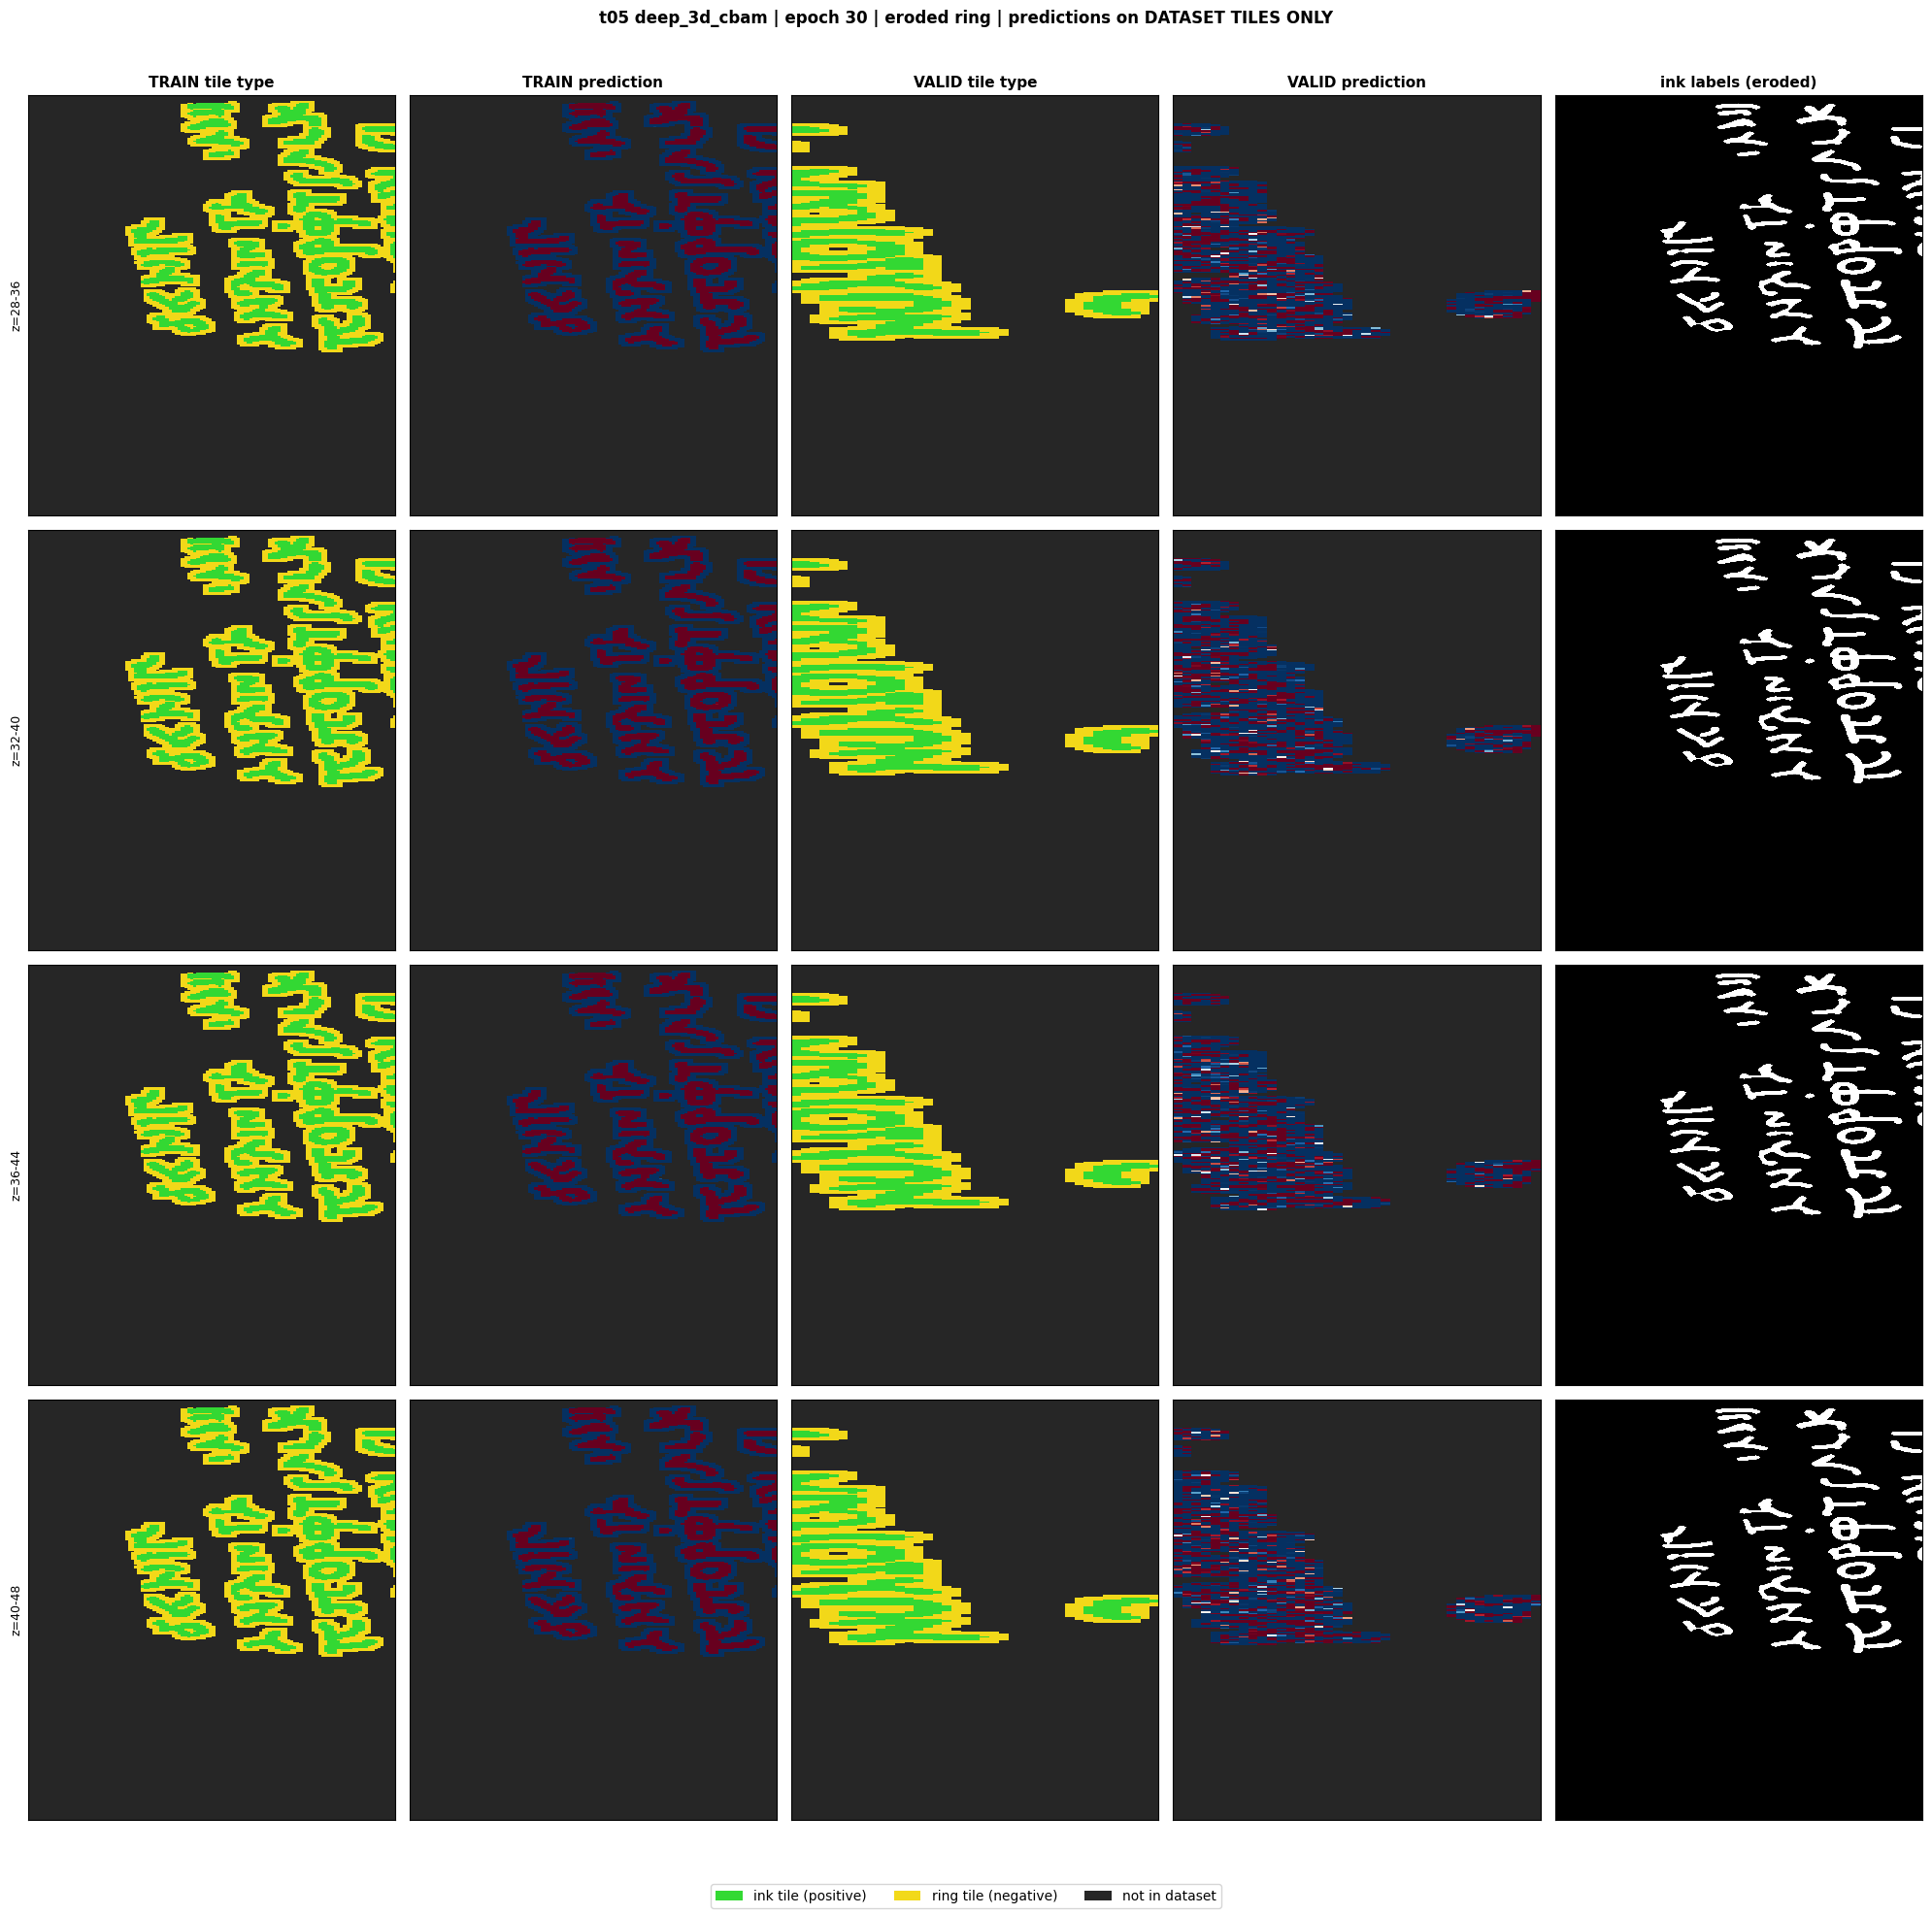

saved ring_training_vis.png


In [7]:
# ── upscale tile map to pixel resolution for overlay ──────────────────────
def upscale(arr, tile):
    """repeat each tile cell into (tile x tile) pixels via nearest-neighbor"""
    return np.repeat(np.repeat(arr, tile, axis=0), tile, axis=1)

# colormap for predictions: 0=dark blue, 0.5=white, 1=dark red
pred_cmap = plt.cm.RdBu_r

# ── plot ───────────────────────────────────────────────────────────────────
n_windows = len(z_starts)
n_cols    = 5  # train_type | train_pred | valid_type | valid_pred | ink_label

fig, axes = plt.subplots(n_windows, n_cols,
                          figsize=(n_cols * 4, n_windows * 5),
                          squeeze=False)

col_titles = ['TRAIN tile type', 'TRAIN prediction', 'VALID tile type', 'VALID prediction', 'ink labels (eroded)']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold')

for row, z in enumerate(z_starts):
    pmap = pred_maps[row]

    # split tile maps
    tt_train, tt_valid = split(tile_type)
    pm_train, pm_valid = split(pmap)

    # label split (pixel level, then downscale to tile for display)
    label_pix_train = labels_ero[:n_ty*TILE, :split_tx*TILE]
    label_pix_valid = labels_ero[:n_ty*TILE, split_tx*TILE:n_tx*TILE]

    # tile type maps (upscaled)
    tt_train_rgb = tile_type_rgb(tt_train)
    tt_valid_rgb = tile_type_rgb(tt_valid)

    # prediction maps: NaN → mask with gray
    def pred_img(pm):
        img = pred_cmap(pm)[:, :, :3]   # RGBA → RGB
        nan_mask = np.isnan(pm)
        img[nan_mask] = [0.15, 0.15, 0.15]
        return img

    row_label = f'z={z}-{z+DEPTH}'

    for col, img in enumerate([
        tt_train_rgb,
        pred_img(pm_train),
        tt_valid_rgb,
        pred_img(pm_valid),
        label_pix_train,
    ]):
        ax = axes[row, col]
        ax.imshow(img if img.ndim == 3 else img, aspect='auto', cmap='gray' if img.ndim == 2 else None,
                  interpolation='nearest')
        ax.set_ylabel(row_label if col == 0 else '', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

# legend
legend_elements = [
    Patch(facecolor=[0.2, 0.85, 0.2], label='ink tile (positive)'),
    Patch(facecolor=[0.95, 0.85, 0.1], label='ring tile (negative)'),
    Patch(facecolor=[0.15, 0.15, 0.15], label='not in dataset'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, frameon=True)
fig.suptitle(f't05 deep_3d_cbam | epoch 30 | eroded ring | predictions on DATASET TILES ONLY',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig('ring_training_vis.png', dpi=120, bbox_inches='tight')
plt.show()
print('saved ring_training_vis.png')

In [8]:
# ── summary stats: what fraction of ink/ring tiles does the model get right? 
print('=== per-window accuracy on dataset tiles ===')
for row, z in enumerate(z_starts):
    pmap = pred_maps[row]
    ink_scores  = pmap[tile_type == 1]
    ring_scores = pmap[tile_type == 2]
    ink_scores  = ink_scores[~np.isnan(ink_scores)]
    ring_scores = ring_scores[~np.isnan(ring_scores)]

    ink_tp  = (ink_scores  > 0.5).mean() if len(ink_scores)  else float('nan')
    ring_tn = (ring_scores < 0.5).mean() if len(ring_scores) else float('nan')
    print(f'  z={z}-{z+DEPTH}: ink recall={ink_tp:.3f}  ring specificity={ring_tn:.3f}  '
          f'(n_ink={len(ink_scores)} n_ring={len(ring_scores)})')

=== per-window accuracy on dataset tiles ===
  z=28-36: ink recall=0.886  ring specificity=0.951  (n_ink=3883 n_ring=5070)
  z=32-40: ink recall=0.894  ring specificity=0.953  (n_ink=3883 n_ring=5070)
  z=36-44: ink recall=0.890  ring specificity=0.948  (n_ink=3883 n_ring=5070)
  z=40-48: ink recall=0.877  ring specificity=0.940  (n_ink=3883 n_ring=5070)


In [9]:
# ── replicate the EXACT eval figure: full papyrus mask, inferno colormap ──
# this is what the training visualizer produces — all papyrus tiles, not just ring
# lets us directly compare: do the ring/ink tiles look correct here too?

pred_maps_full = []

with torch.no_grad():
    for z in tqdm(z_starts, desc='full-mask depth windows'):
        pmap = np.full((n_ty, n_tx), np.nan, dtype=np.float32)
        queue = []
        for ty in range(n_ty):
            for tx in range(n_tx):
                y0, x0 = ty * TILE, tx * TILE
                # use full papyrus mask, same as the eval visualizer
                if full_mask[y0:y0+TILE, x0:x0+TILE].sum() == 0:
                    continue
                queue.append((ty, tx, y0, x0))

        for batch_start in range(0, len(queue), BATCH):
            batch = queue[batch_start:batch_start + BATCH]
            tiles = []
            for ty, tx, y0, x0 in batch:
                blk = np.array(vol[z:z+DEPTH, y0:y0+TILE, x0:x0+TILE]).astype(np.float32)
                # replicate predict_tiles normalization exactly
                blk = (blk - mean) / std
                m_bin = (full_mask[y0:y0+TILE, x0:x0+TILE] > 0).astype(np.uint8)
                blk[np.broadcast_to(np.expand_dims(m_bin, 0), blk.shape) == 0] = 0
                blk = np.clip((blk - g_min) / (g_max - g_min + 1e-12), 0, 1)
                tiles.append(blk)
            tensor = torch.tensor(np.stack(tiles), dtype=torch.float32).unsqueeze(1).to(c.device)
            scores = torch.sigmoid(model(tensor)).cpu().numpy().flatten()
            for i, (ty, tx, _, _) in enumerate(batch):
                pmap[ty, tx] = scores[i]

        pred_maps_full.append(pmap)

print('full-mask inference complete')

full-mask depth windows: 100%|██████████| 4/4 [12:33<00:00, 188.45s/it]

full-mask inference complete


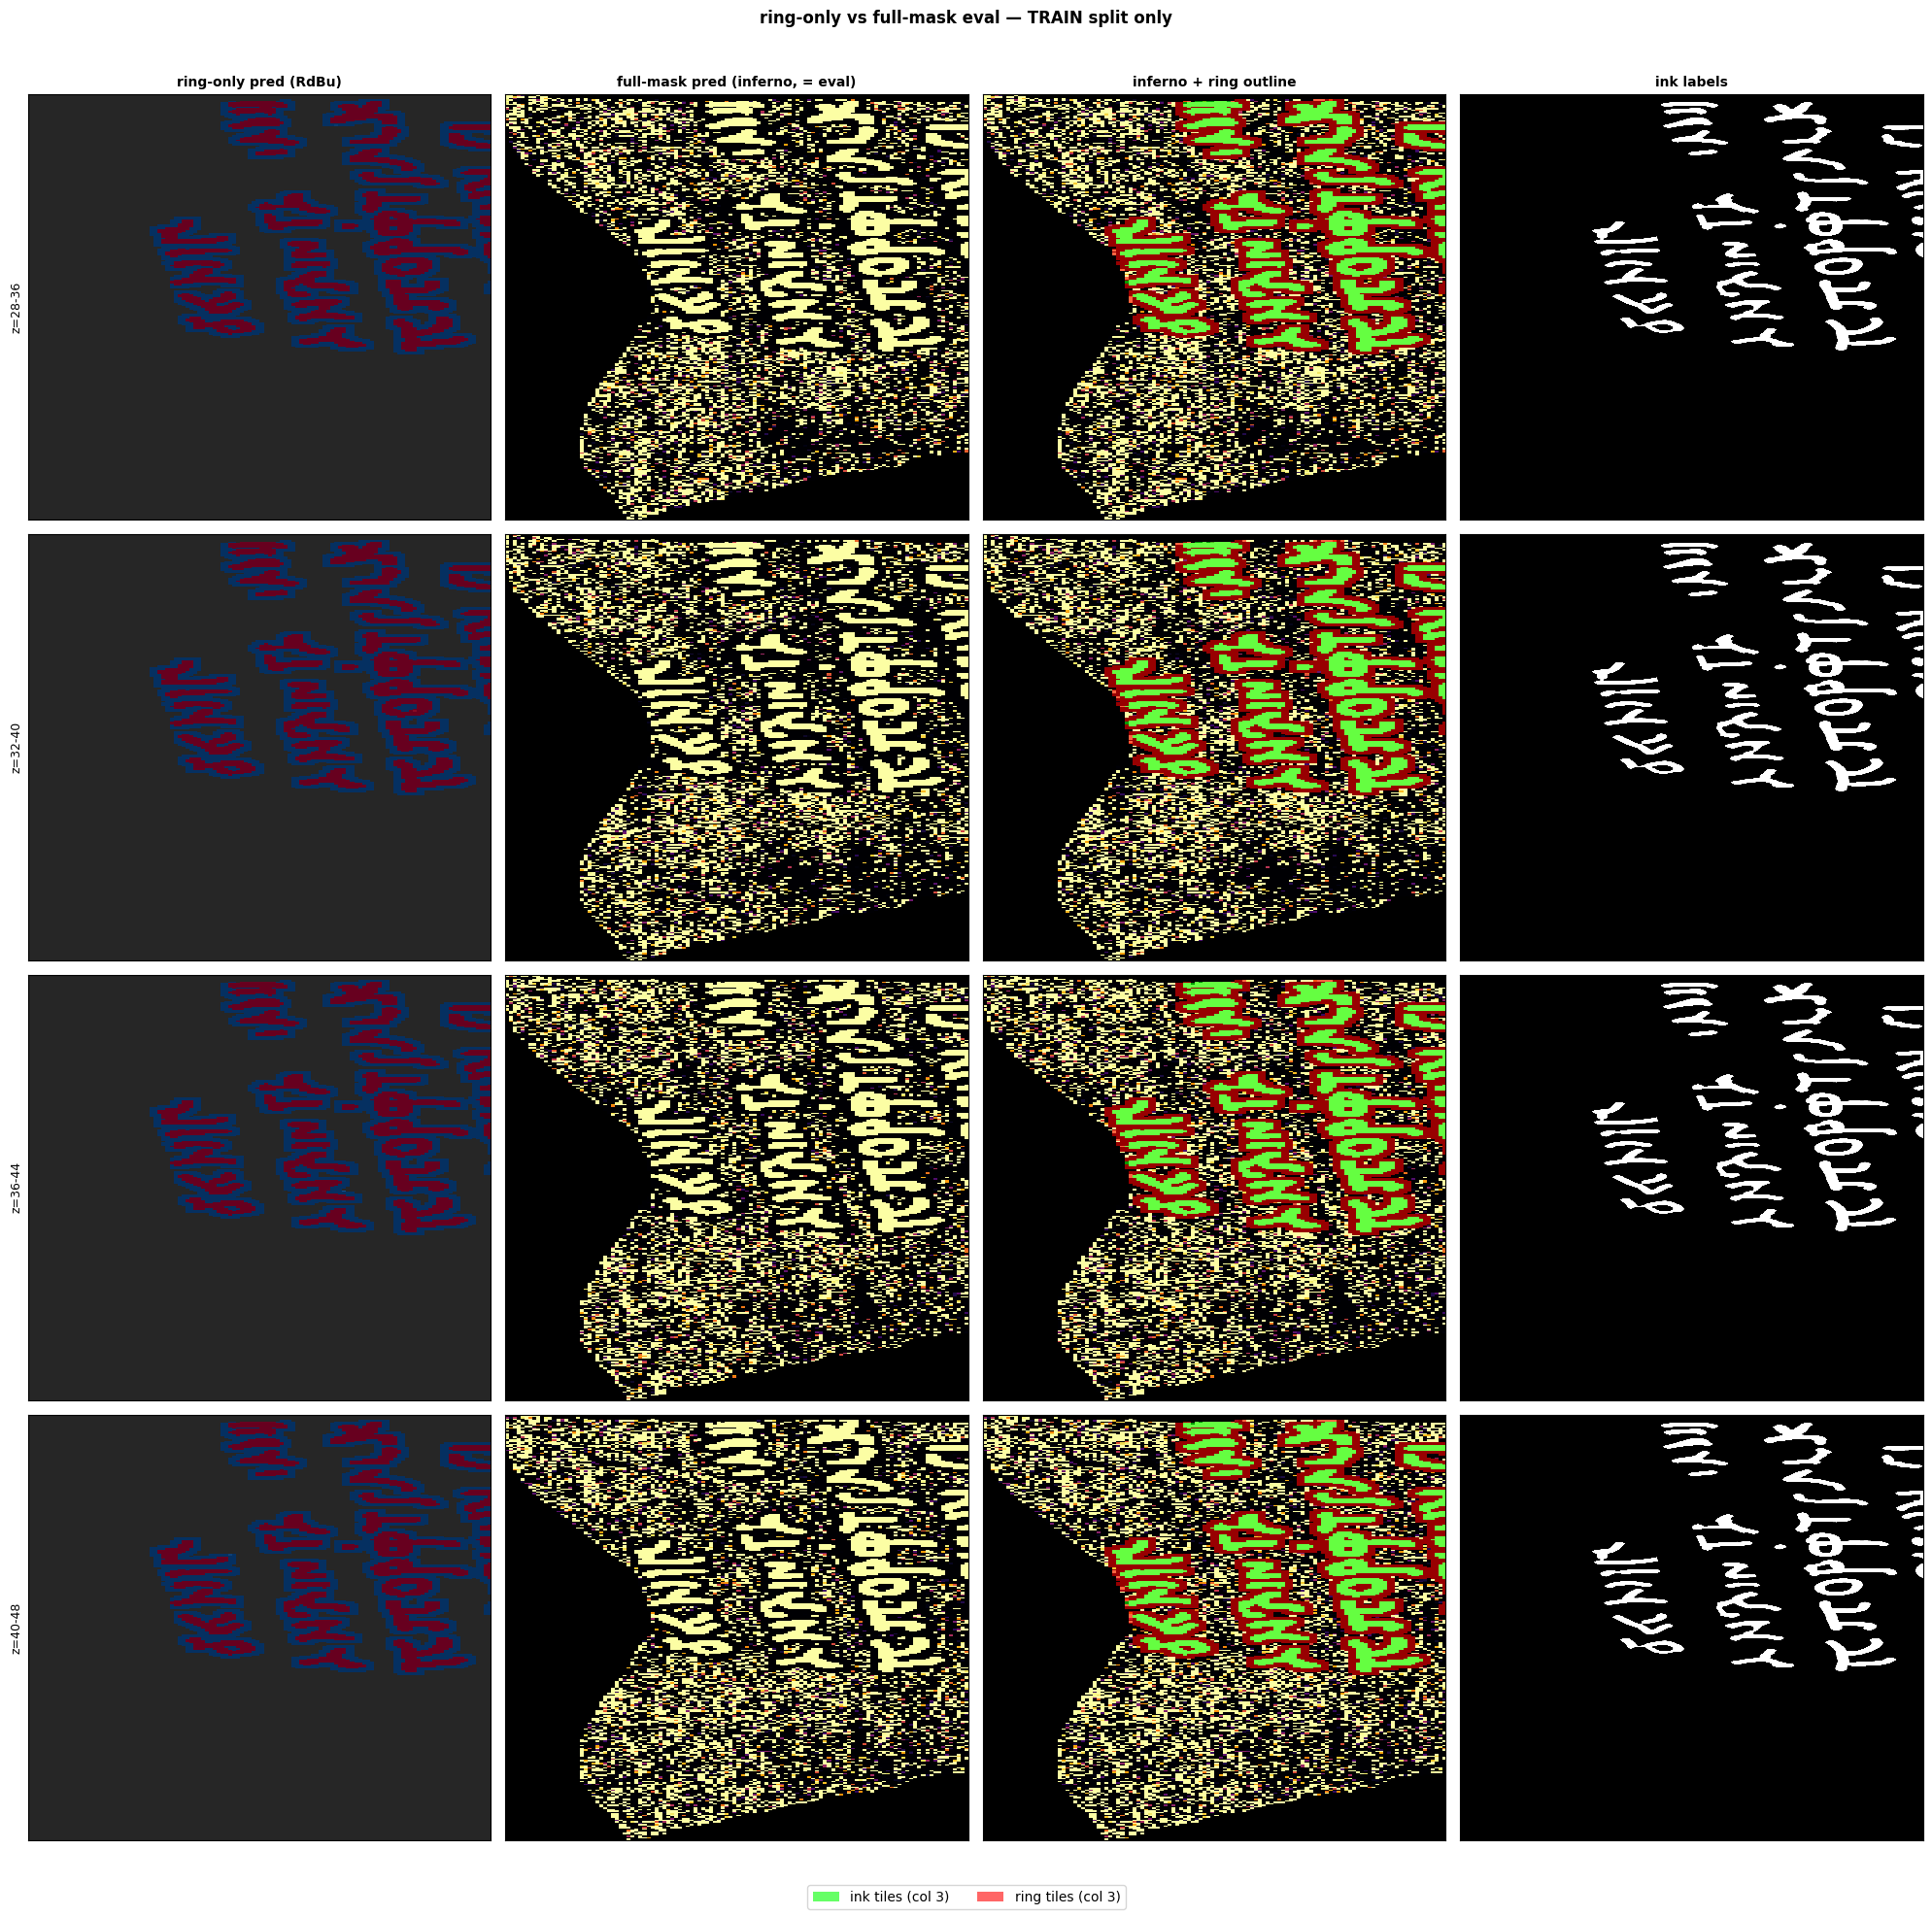

saved ring_vs_eval_vis.png


In [10]:
# ── side-by-side: ring-only (our vis) vs full-mask (eval vis) ─────────────
# each row = one depth window
# col 0: ring-only prediction (RdBu, NaN=gray)     ← our notebook
# col 1: full-mask prediction (inferno, NaN=nan)    ← training eval figure
# col 2: full-mask prediction with ring tiles circled in red
# col 3: ink labels for reference

inferno_nan = plt.cm.inferno.copy()
inferno_nan.set_bad(color='black')

fig2, axes2 = plt.subplots(n_windows, 4,
                            figsize=(4 * 5, n_windows * 5),
                            squeeze=False)

col2_titles = ['ring-only pred (RdBu)', 'full-mask pred (inferno, = eval)', 'inferno + ring outline', 'ink labels']
for col, title in enumerate(col2_titles):
    axes2[0, col].set_title(title, fontsize=10, fontweight='bold')

for row, z in enumerate(z_starts):
    pm_ring = pred_maps[row]       # NaN outside ring
    pm_full = pred_maps_full[row]  # NaN outside papyrus

    pm_ring_train, _ = split(pm_ring)
    pm_full_train, _ = split(pm_full)
    tt_train, _      = split(tile_type)
    label_train      = labels_ero[:n_ty*TILE, :split_tx*TILE]

    # col 0: ring-only RdBu
    def pred_img_rdbu(pm):
        img = pred_cmap(pm)[:, :, :3]
        img[np.isnan(pm)] = [0.15, 0.15, 0.15]
        return img

    # col 1: inferno on full mask (exact eval rendering)
    pm_full_masked = np.where(np.isnan(pm_full_train), np.nan, pm_full_train)

    # col 2: inferno + red outlines on ring tiles
    ring_outline = np.zeros((*pm_full_train.shape, 4), dtype=np.float32)
    ring_outline[tt_train == 1] = [0, 1, 0, 0.6]   # green = ink
    ring_outline[tt_train == 2] = [1, 0, 0, 0.6]   # red   = ring

    row_label = f'z={z}-{z+DEPTH}'

    for col, content in enumerate([
        ('img', pred_img_rdbu(pm_ring_train), None),
        ('img', pm_full_masked, inferno_nan),
        ('img+overlay', pm_full_masked, ring_outline),
        ('gray', label_train, None),
    ]):
        ax = axes2[row, col]
        kind = content[0]
        if kind == 'gray':
            ax.imshow(content[1], cmap='gray', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
        elif kind == 'img+overlay':
            ax.imshow(content[1], cmap=inferno_nan, aspect='auto', interpolation='nearest', vmin=0, vmax=1)
            ax.imshow(content[2], aspect='auto', interpolation='nearest')
        else:
            cmap = content[2] if content[2] is not None else None
            kw = dict(vmin=0, vmax=1) if cmap is not None else {}
            ax.imshow(content[1], cmap=cmap, aspect='auto', interpolation='nearest', **kw)
        ax.set_ylabel(row_label if col == 0 else '', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

legend2 = [
    Patch(facecolor=[0, 1, 0, 0.6], label='ink tiles (col 3)'),
    Patch(facecolor=[1, 0, 0, 0.6], label='ring tiles (col 3)'),
]
fig2.legend(handles=legend2, loc='lower center', ncol=2, fontsize=10)
fig2.suptitle('ring-only vs full-mask eval — TRAIN split only', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('ring_vs_eval_vis.png', dpi=120, bbox_inches='tight')
plt.show()
print('saved ring_vs_eval_vis.png')

Model parameters (v10_deep_3d_cbam): 3,604,769
epoch 20 ink recall=0.898  ring specificity=0.916
epoch 30 ink recall=0.886  ring specificity=0.951


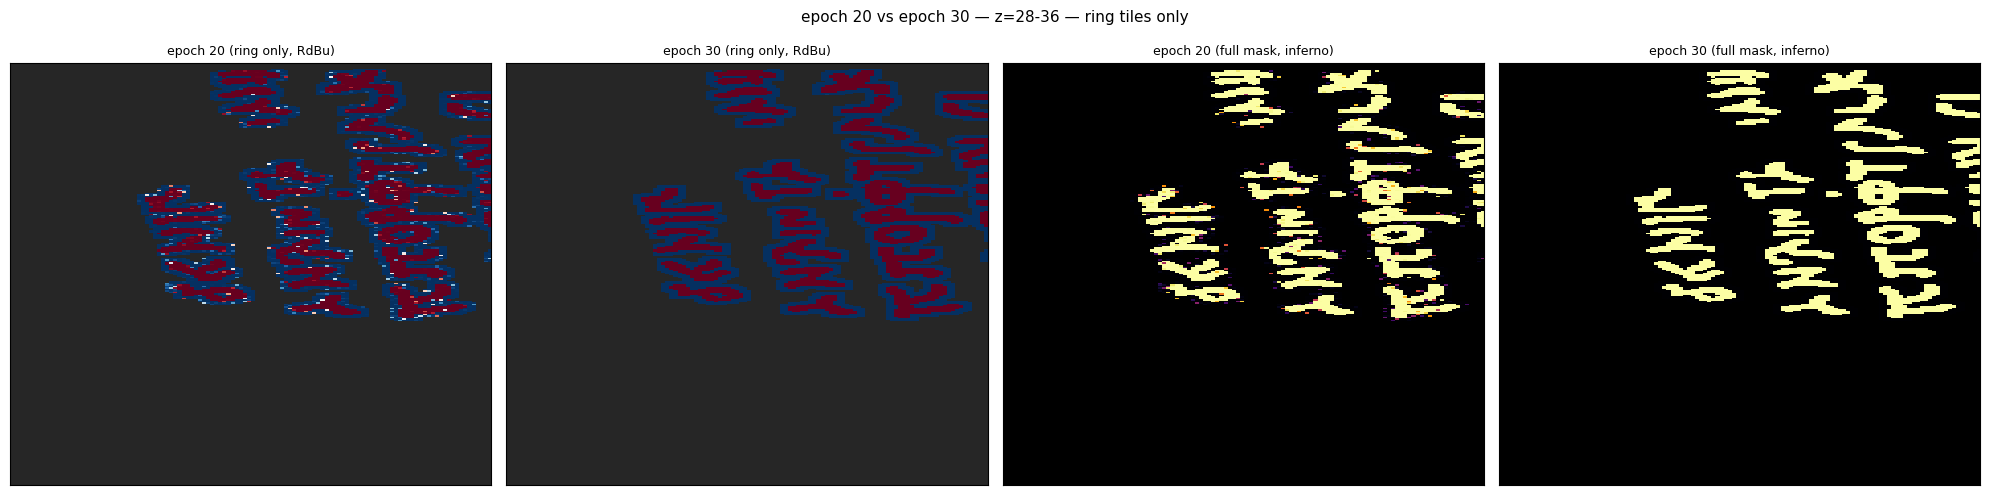

note: if epoch 20 looks noisier, the eval figure noise was just the mid-training checkpoint


In [11]:
# ── confirm by loading epoch 20 model and comparing predictions ──────────
# if the "noise in eval" is just the model mid-training, epoch 20 should look noisier
MODEL_EPOCH20 = r'C:\Users\ChenJeff\Documents\vesuvius\models\model_epoch_20.pth'

model_e20, _ = create_model(c)
state_e20 = torch.load(MODEL_EPOCH20, map_location=c.device)
model_e20.load_state_dict(state_e20)
model_e20.eval()
model_e20 = model_e20.to(c.device)

# run inference on ring tiles only, first z window
z = z_starts[0]
queue = [(ty, tx, ty*TILE, tx*TILE) for ty in range(n_ty) for tx in range(n_tx) if tile_type[ty,tx] != 0]

pmap_e20 = np.full((n_ty, n_tx), np.nan, dtype=np.float32)
pmap_e30 = pred_maps[0].copy()  # already computed

with torch.no_grad():
    for batch_start in range(0, len(queue), BATCH):
        batch = queue[batch_start:batch_start+BATCH]
        tiles = [normalize(np.array(vol[z:z+DEPTH, y0:y0+TILE, x0:x0+TILE])) for _, _, y0, x0 in batch]
        tensor = torch.tensor(np.stack(tiles), dtype=torch.float32).unsqueeze(1).to(c.device)
        scores = torch.sigmoid(model_e20(tensor)).cpu().numpy().flatten()
        for i, (ty, tx, _, _) in enumerate(batch):
            pmap_e20[ty, tx] = scores[i]

# compare epoch 20 vs epoch 30 on ring tiles
ink_e20  = pmap_e20[tile_type == 1]; ink_e20  = ink_e20[~np.isnan(ink_e20)]
ring_e20 = pmap_e20[tile_type == 2]; ring_e20 = ring_e20[~np.isnan(ring_e20)]
ink_e30  = pmap_e30[tile_type == 1]; ink_e30  = ink_e30[~np.isnan(ink_e30)]
ring_e30 = pmap_e30[tile_type == 2]; ring_e30 = ring_e30[~np.isnan(ring_e30)]

print(f'epoch 20 ink recall={( ink_e20>0.5).mean():.3f}  ring specificity={(ring_e20<0.5).mean():.3f}')
print(f'epoch 30 ink recall={( ink_e30>0.5).mean():.3f}  ring specificity={(ring_e30<0.5).mean():.3f}')

fig3, axes3 = plt.subplots(1, 4, figsize=(20, 5))
for ax, pm, title in zip(axes3,
    [pmap_e20, pmap_e30, pmap_e20, pmap_e30],
    ['epoch 20 (ring only, RdBu)', 'epoch 30 (ring only, RdBu)',
     'epoch 20 (full mask, inferno)', 'epoch 30 (full mask, inferno)']):
    if 'inferno' in title:
        pf = pred_maps_full[0] if 'epoch 30' in title else pmap_e20  # placeholder
        # rebuild full map for e20
        if 'epoch 20' in title:
            pf_e20 = np.full((n_ty, n_tx), np.nan, dtype=np.float32)
            for ty in range(n_ty):
                for tx in range(n_tx):
                    if not np.isnan(pmap_e20[ty,tx]) or tile_type[ty,tx]==0:
                        pf_e20[ty,tx] = pmap_e20[ty,tx]  # ring only, rest stays NaN
            pm_show, _ = split(pf_e20)
        else:
            pm_show, _ = split(pmap_e30)
        ax.imshow(pm_show, cmap=inferno_nan, vmin=0, vmax=1, aspect='auto', interpolation='nearest')
    else:
        pm_show, _ = split(pm)
        img = pred_cmap(pm_show)[:,:,:3]
        img[np.isnan(pm_show)] = [0.15,0.15,0.15]
        ax.imshow(img, aspect='auto', interpolation='nearest')
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

fig3.suptitle(f'epoch 20 vs epoch 30 — z={z}-{z+DEPTH} — ring tiles only', fontsize=11)
plt.tight_layout()
plt.show()
print('note: if epoch 20 looks noisier, the eval figure noise was just the mid-training checkpoint')

In [ ]:
# ── score distribution: epoch 20 vs epoch 30 ────────────────────────────
# recall only tells you what fraction cross 0.5 — it says nothing about HOW FAR
# above 0.5 they are. in inferno: score 0.6 = orange (looks like noise),
# score 0.99 = white (looks like clean letters). both cross the 0.5 threshold.
import matplotlib.pyplot as plt
import numpy as np

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 8))

for row, (label, pmap) in enumerate([('epoch 20', pmap_e20), ('epoch 30', pmap_e30)]):
    ink_s  = pmap[tile_type == 1]; ink_s  = ink_s[~np.isnan(ink_s)]
    ring_s = pmap[tile_type == 2]; ring_s = ring_s[~np.isnan(ring_s)]

    # histogram
    ax = axes4[row, 0]
    ax.hist(ink_s,  bins=50, alpha=0.7, color='green',  label=f'ink  (n={len(ink_s)})',  density=True)
    ax.hist(ring_s, bins=50, alpha=0.7, color='orange', label=f'ring (n={len(ring_s)})', density=True)
    ax.axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
    ax.set_title(f'{label} — score distribution')
    ax.set_xlabel('model score')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

    # inferno visualization showing actual score values (not binarized)
    pm_show, _ = split(pmap)
    ax2 = axes4[row, 1]
    ax2.imshow(pm_show, cmap=inferno_nan, vmin=0, vmax=1, aspect='auto', interpolation='nearest')
    ax2.set_title(f'{label} — inferno score map (ring tiles only)')
    ax2.set_xticks([]); ax2.set_yticks([])

    print(f'{label}:')
    print(f'  ink  — mean={ink_s.mean():.3f}  std={ink_s.std():.3f}  median={np.median(ink_s):.3f}  >0.9: {(ink_s>0.9).mean():.3f}')
    print(f'  ring — mean={ring_s.mean():.3f}  std={ring_s.std():.3f}  median={np.median(ring_s):.3f}  <0.1: {(ring_s<0.1).mean():.3f}')

plt.tight_layout()
plt.show()
# if epoch 20 ink tiles score ~0.6 and epoch 30 ~0.99, that explains everything:
# both >0.5 (same "recall"), but inferno maps 0.6→orange and 0.99→white